In [1]:
# import pickle

# pose = True
# with open("data.pkl", "wb") as f:
#     pickle.dump(pose, f)

# with open("data.pkl", "rb") as f:
#     pose = pickle.load(f)
# pose

In [6]:
import mediapipe as mp
import cv2
import numpy as np

In [7]:
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

In [3]:
import mediapipe as mp
import cv2
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from collections import deque

def calculate_loss(predicted, actual):
    mae_loss = nn.MSELoss()
    loss = mae_loss(torch.tensor(predicted),torch.tensor(actual))
    return loss.item()

def calculate_angle(a, b, c):
    a = np.array(a)  # First
    b = np.array(b)  # Mid
    c = np.array(c)  # End
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# Load the LSTM model

lstm_model = torch.jit.load(r'model_path/model_squats_scripted.pt')#for linux relative path
lstm_model.to(device) 
lstm_model.eval()
# Initialize MediaPipe pose
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Video Capture
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

# Variables for counting and tracking
stage = ""
counter = 0

# Scaling angles
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array([[0] * 7, [180] * 7]))


input_window= 20
output_window = 5
pred_freq = 5

# Store pose sequences
pose_sequences = deque(maxlen=input_window )
real_time_storage = []
frame_count = 0
collecting_real_time = False #this is a flag.false-during prediction, true-calculating real time values. 
predicted_vs_real_storage = [] 
focus_angles=[]
realtime_loss = []
run_buffer=[]
loss_buffer=[]
threshold=300
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        # Detect pose
        results = pose.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            # Draw pose landmarks
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                                      mp_drawing.DrawingSpec(color=(0,0,255), thickness=2, circle_radius=2))

            # Define angles to calculate
            angles_to_calculate = {
                "right_elbow_right_shoulder_right_hip": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                ],
                "left_elbow_left_shoulder_left_hip": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                ],
                "right_knee_mid_hip_left_knee": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x) / 2,
                     (landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y) / 2],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                ],
                "right_hip_right_knee_right_ankle": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y],
                ],
                "left_hip_left_knee_left_ankle": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y],
                ],
                "right_wrist_right_elbow_right_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                ],
                "left_wrist_left_elbow_left_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                ],
            }

            # Compute angles
            angles = [calculate_angle(*angles_to_calculate[key]) for key in angles_to_calculate]
            print(f"Calculated Angles: {angles}")

            # Input is normalized and added to sequence
            normalized_angles = scaler.transform([angles])
            pose_sequences.append(normalized_angles[0])
            
            # Collecting real-time frames(it checks if 20 new angles are appended,later forms paird of predictions and their actual angles)
            if collecting_real_time:#if flag is true
                real_time_storage.append(angles)
                frame_count += 1  # Count frames collected
                if frame_count == output_window:  # Ensure it's the same number as predicted
                    # Store the actual vs predicted values correctly
                    predicted_vs_real_storage.append((predicted_angles.copy(), real_time_storage.copy())) 

                    # Extract key angles for evaluation
                    predicted_focus = [[list(pred[3:5]) for pred in group[0]] for group in predicted_vs_real_storage]  
                    real_focus = [[list(real[3:5])for real in group[1]] for group in predicted_vs_real_storage]  

                    focus_angles = list(zip(predicted_focus, real_focus))
                    realtime_loss.append(calculate_loss(predicted=focus_angles[-1][0], actual=focus_angles[-1][1]))

                    run_buffer.append(focus_angles[-1][1])
                    if len(run_buffer)> 3:
                        run_buffer.pop(0)

                    loss_buffer.append(realtime_loss[-1])
                    if len(loss_buffer) > 3:
                        loss_buffer.pop(0)
        
                    # Reset collection
                    collecting_real_time = False  
                    real_time_storage = []  
                    frame_count = 0 
                    
            # Prediction
            if len(pose_sequences) == input_window  and not collecting_real_time:# if flag is false
                input_window_degrees = scaler.inverse_transform(np.array(pose_sequences))
                print(f" Input Window (Degrees) Before Prediction:\n{input_window_degrees}") 
                input_seq = torch.tensor([pose_sequences], dtype=torch.float32).to(device)
                with torch.no_grad():
                    predicted_normalized = lstm_model(input_seq).cpu().numpy().squeeze(0)
                predicted_angles = scaler.inverse_transform(predicted_normalized)
                
                print(f"Predicted Angles:{predicted_angles}")
                real_time_storage = []  
                collecting_real_time = True  
                frame_count = 0 
                
                # Sliding window for input
                pose_sequences = deque(list(pose_sequences)[pred_freq:], maxlen=input_window)#removes previous 20 frames
                pose_sequences.extend(real_time_storage[:pred_freq])#appends new 20 frames to remaining 30 frames
                real_time_storage = []  
                collecting_real_time = True  
                
                # i have not focused on camera written display 
                for i, angle in enumerate(predicted_angles[0]):
                    cv2.putText(image, f'Predicted {i+1}: {int(angle)}', (50, 300 + i * 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        # Show output
        cv2.imshow('Pose Estimation', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):

            break

cap.release()
cv2.destroyAllWindows()

W0000 00:00:1741702302.231493   30530 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1741702302.318364   30532 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Calculated Angles: [12.695115237067549, 16.270293923398842, 19.960416261303493, 179.2546815183271, 176.8470027167921, 176.86299824011417, 174.73166985526612]
Calculated Angles: [9.358066017316062, 16.78053345540273, 19.97076477383174, 177.51482947091964, 177.3285307293245, 174.67786437671546, 173.71334556752547]
Calculated Angles: [7.084657066951563, 19.45672552200485, 20.72635328354406, 174.01831834863899, 177.88484584349183, 174.96262564034186, 169.87274296474035]
Calculated Angles: [9.704532403117344, 21.17167829553737, 22.464174493751983, 172.28297469926466, 178.90291939457492, 177.8174025971467, 161.12296451710765]
Calculated Angles: [12.082750859561132, 22.59457428801986, 22.596100976490533, 172.11452281418076, 179.79384104768283, 172.2671652653309, 153.75714525695486]
Calculated Angles: [14.456321136906798, 15.832057244489059, 22.097789219958432, 175.18834440184568, 178.97422291727491, 165.86005797836881, 161.28337561874383]
Calculated Angles: [15.798936543155842, 14.14899783328

In [72]:
len(focus_angles)

208

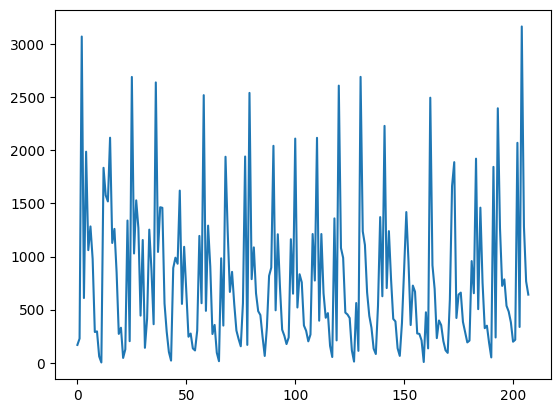

In [73]:
import matplotlib.pyplot as plt  
plt.plot(realtime_loss)

In [74]:
for index, loss in enumerate(realtime_loss):
    print(index, int(loss))

0 167
1 226
2 3071
3 609
4 1987
5 1059
6 1283
7 977
8 288
9 294
10 58
11 1
12 1835
13 1576
14 1518
15 2118
16 1127
17 1260
18 851
19 270
20 329
21 44
22 125
23 1338
24 202
25 2691
26 1028
27 1528
28 1268
29 443
30 1155
31 140
32 414
33 1253
34 874
35 362
36 2639
37 1043
38 1464
39 1458
40 557
41 291
42 100
43 19
44 891
45 988
46 931
47 1620
48 553
49 1091
50 665
51 244
52 274
53 134
54 115
55 301
56 1194
57 560
58 2519
59 488
60 1290
61 905
62 270
63 355
64 93
65 14
66 983
67 349
68 1939
69 1235
70 666
71 855
72 553
73 303
74 223
75 154
76 560
77 1942
78 167
79 2541
80 786
81 1085
82 653
83 485
84 448
85 244
86 63
87 334
88 817
89 895
90 2042
91 493
92 1209
93 710
94 311
95 254
96 175
97 237
98 1162
99 649
100 2110
101 519
102 832
103 757
104 349
105 300
106 201
107 265
108 1211
109 773
110 2117
111 395
112 1211
113 653
114 423
115 466
116 158
117 53
118 1359
119 209
120 2609
121 1080
122 987
123 471
124 453
125 420
126 116
127 10
128 561
129 111
130 2692
131 1237
132 1108
133 660
134 

In [75]:
# threshold = 250 for 3 or more iterations
import pandas as pd
# pd.DataFrame(focus_angles[0][1])
# len(focus_angles)
column = 90
pre = focus_angles[column][0] #pred
act = focus_angles[column][1] #real
# pd.DataFrame({"predicted": pre,"actual":act})
pre, act, realtime_loss[column]

([[105.622856, 91.6917],
  [106.40327, 90.71585],
  [109.73408, 92.439674],
  [114.977135, 95.7823],
  [118.49784, 98.408585]],
 [[134.4147681541741, 137.30272713080393],
  [140.79128760238316, 143.07998339057818],
  [146.9600431248838, 148.31693509623977],
  [151.3609337580167, 152.4536059034101],
  [153.9113469690597, 155.8064545158281]],
 2042.5968086314901)

In [76]:
import torch
import torch.nn as nn
# column = 58
pre = focus_angles[column][0]
act = focus_angles[column][1]

mae_loss = nn.MSELoss()
loss = mae_loss(torch.tensor(pre),torch.tensor(act))
loss.item()

2042.5968086314901

In [77]:
focus_angles[0][1]

[[153.03375613858702, 155.93678629118963],
 [148.63491680010975, 152.5169993075379],
 [144.47304846575815, 149.00118136206376],
 [139.28519043828095, 145.75539761873927],
 [130.89724238446803, 139.0618348709193]]

In [78]:
left_knee_list_real = []
for run in focus_angles:
    for angle in run[1]:
        left_knee_list_real.append(angle[0])

left_knee_list_pred = []
for run in focus_angles:
    for angle in run[0]:
        left_knee_list_pred.append(angle[0])

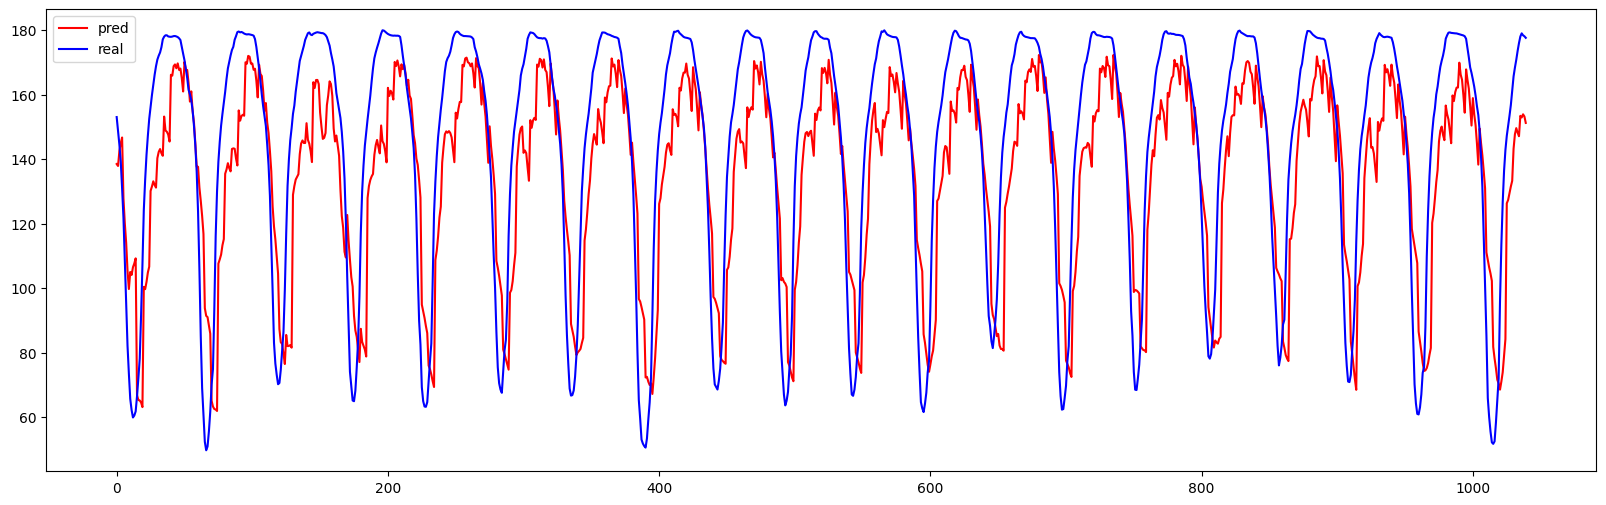

In [86]:
plt.figure(figsize=(20, 6))
plt.plot(left_knee_list_pred, label="pred", color="red")
plt.plot(left_knee_list_real, label="real", color="blue")
plt.legend()
plt.show()

# Make Basic Detection

In [3]:
# Getting video feed
cap = cv2.VideoCapture(0)
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()

        # Recolor image to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False 

        # Make detection
        results = pose.process(image)
        
        # Recolor back to BGR
        image.flags.writeable = True 
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Extract landmarks
        try:
            landmarks = results.pose_landmarks.landmark
            print(landmarks)
        except:
            pass

        # Rendering
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                  mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=2),
                                  mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2),
                                  )

        cv2.imshow('Raw Webcam Feed', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# Extract keypoints from a video 

In [147]:
import mediapipe as mp
import cv2
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from collections import deque

def calculate_loss(predicted, actual):
    mae_loss = nn.MSELoss()
    loss = mae_loss(torch.tensor(predicted),torch.tensor(actual))
    return loss.item()

def calculate_angle(a, b, c):
    a = np.array(a)  # First
    b = np.array(b)  # Mid
    c = np.array(c)  # End
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# Load the LSTM model

lstm_model = torch.jit.load(r'model_path/model_squats_scripted.pt')#for linux relative path
lstm_model.to(device) 
lstm_model.eval()
# Initialize MediaPipe pose
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Video Capture
cap = cv2.VideoCapture("/home/tanmaymistry/Desktop/codes/myapps/beproj-crunch/Rehabilitation-System/data/hakli_squats_1.mp4")
# cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
# cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

# Variables for counting and tracking
stage = ""
counter = 0

# Scaling angles
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array([[0] * 7, [180] * 7]))


input_window= 20
output_window = 5
pred_freq = 5

# Store pose sequences
pose_sequences = deque(maxlen=input_window )
real_time_storage = []
frame_count = 0
collecting_real_time = False #this is a flag.false-during prediction, true-calculating real time values. 
predicted_vs_real_storage = [] 
focus_angles=[]
realtime_loss = []
run_buffer=[]
loss_buffer=[]
threshold=300
count = 0
df = pd.DataFrame(columns=["frame_order","right_elbow_right_shoulder_right_hip", "left_elbow_left_shoulder_left_hip", "right_knee_mid_hip_left_knee", "right_hip_right_knee_right_ankle",
                            "left_hip_left_knee_left_ankle", "right_wrist_right_elbow_right_shoulder", "left_wrist_left_elbow_left_shoulder"])
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        # Detect pose
        results = pose.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            # Draw pose landmarks
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                                      mp_drawing.DrawingSpec(color=(0,0,255), thickness=2, circle_radius=2))

            # Define angles to calculate
            angles_to_calculate = {
                "right_elbow_right_shoulder_right_hip": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                ],
                "left_elbow_left_shoulder_left_hip": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                ],
                "right_knee_mid_hip_left_knee": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x) / 2,
                     (landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y) / 2],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                ],
                "right_hip_right_knee_right_ankle": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y],
                ],
                "left_hip_left_knee_left_ankle": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y],
                ],
                "right_wrist_right_elbow_right_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                ],
                "left_wrist_left_elbow_left_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                ],
            }
            # Compute angles
            angles = [calculate_angle(*angles_to_calculate[key]) for key in angles_to_calculate]
            # print(f"Calculated Angles: {angles}")
            # print(angles)
            angles = [int(count)] + angles
            df.loc[count] = angles
            count += 1

        # Show output
        cv2.imshow('Pose Estimation', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):

            break

cap.release()
cv2.destroyAllWindows()

W0000 00:00:1741707476.597506   58446 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1741707476.649552   58447 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [148]:
df["frame_order"] = df["frame_order"].astype(int)
df.head()

,frame_order,right_elbow_right_shoulder_right_hip,left_elbow_left_shoulder_left_hip,right_knee_mid_hip_left_knee,right_hip_right_knee_right_ankle,left_hip_left_knee_left_ankle,right_wrist_right_elbow_right_shoulder,left_wrist_left_elbow_left_shoulder
0,0,20.860193,16.034512,28.925374,177.344150,177.770924,176.154408,161.086469
1,1,19.777086,15.933075,28.994755,177.597040,178.010313,178.760230,161.040051
2,2,18.745600,15.983862,28.944070,177.761838,178.020727,178.572138,161.884094
3,3,18.198449,16.337870,28.891036,178.172410,177.808015,177.528918,161.771075
4,4,17.828334,16.618230,29.056345,178.276824,177.621667,177.073543,161.813922


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

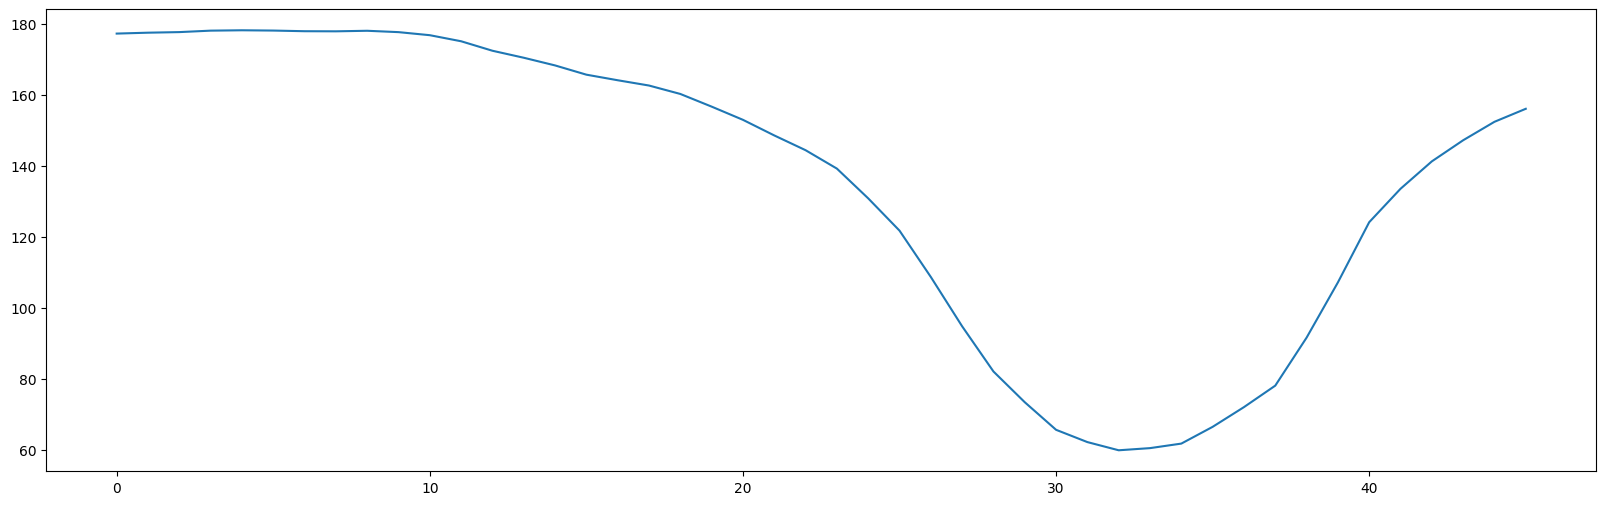

In [151]:
plt.figure(figsize=(20,6))
plt.plot(df.iloc[:,4])
plt.plot

In [101]:
data = [40.292152280872415,
 41.76803187491497,
 32.0649883255575,
 175.04658384066218,
 178.01065096826343,
 23.947889496301663,
 17.870666463195903]

df = pd.DataFrame(columns=["1","2","3","4","5","6","7"])
df.loc[len(df)] = data
df

,1,2,3,4,5,6,7
0,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666


In [116]:
df.loc[len(df)] = data
df

,1,2,3,4,5,6,7
0,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
1,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
2,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
3,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
4,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
5,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
6,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
7,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
8,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
9,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import sys

mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)

cap = cv2.VideoCapture(sys.argv[1])

if cap.isOpened() == False:
    print("Error opening video stream or file")
    raise TypeError

frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

outdir, inputflnm = sys.argv[1][:sys.argv[1].rfind(
    '/')+1], sys.argv[1][sys.argv[1].rfind('/')+1:]
inflnm, inflext = inputflnm.split('.')
out_filename = f'{outdir}{inflnm}_annotated.{inflext}'
out = cv2.VideoWriter(out_filename, cv2.VideoWriter_fourcc(
    'M', 'J', 'P', 'G'), 10, (frame_width, frame_height))

while cap.isOpened():
    ret, image = cap.read()
    if not ret:
        break

    image = cv2.cvtColor(cv2.flip(image, 1), cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = pose.process(image)

    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    mp_drawing.draw_landmarks(
        image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
    out.write(image)
pose.close()
cap.release()
out.release()


# 2. Determining Joints

<img src="https://i.imgur.com/3j8BPdc.png" style="height:300px" >

In [4]:
landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value]

NameError: name 'landmarks' is not defined

In [ ]:
landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value]

x: 1.01653159
y: 0.86054343
z: -1.10317266
visibility: 0.545346856

# 3. Calculate Angles

In [5]:
def calculate_angle(a,b,c):
    a = np.array(a) # First
    b = np.array(b) # Mid
    c = np.array(c) # End
    
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    
    if angle >180.0:
        angle = 360-angle
        
    return angle 

In [6]:
shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
elbow = [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x,landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y]
wrist = [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x,landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y]


NameError: name 'landmarks' is not defined

In [7]:
shoulder, elbow, wrist

NameError: name 'shoulder' is not defined

In [ ]:
calculate_angle(shoulder, elbow, wrist)

158.37397025964307

# Holistic

In [ ]:
# mp_drawing = mp.solutions.drawing_utils
# mp_holistic = mp.solutions.holistic

In [ ]:
# import cv2
# import mediapipe as mp

# mp_drawing = mp.solutions.drawing_utils
# mp_drawing_styles = mp.solutions.drawing_styles
# mp_holistic = mp.solutions.holistic
# mp_face_mesh = mp.solutions.face_mesh_connections  # Import face_mesh for FACE_CONNECTIONS

# cap = cv2.VideoCapture(0)

# # Initiate holistic model
# with mp_holistic.Holistic(min_detection_confidence=0.5, 
#                           min_tracking_confidence=0.5,
#                           static_image_mode=False,
#                           smooth_landmarks=True,
#                           model_complexity=2
#                             ) as holistic:
    
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor Feed
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False        
        
#         # Make Detections
#         results = holistic.process(image)
        
#         # Recolor image back to BGR for rendering
#         image.flags.writeable = True   
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         # 1. Draw face landmarks
#         mp_drawing.draw_landmarks(
#             image, results.face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,  # Use FACE_CONNECTIONS from face_mesh module
#             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
#             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
#         )
        
#         # 2. Right hand
#         mp_drawing.draw_landmarks(
#             image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
#         )

#         # 3. Left Hand
#         mp_drawing.draw_landmarks(
#             image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
#         )

#         # 4. Pose Detections
#         mp_drawing.draw_landmarks(
#             image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
#         )
                        
#         cv2.imshow('Holistic Webcam Feed', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


In [ ]:
# SPINE ANGLE

In [ ]:
# import cv2
# import mediapipe as mp
# import numpy as np

# mp_drawing = mp.solutions.drawing_utils
# mp_pose = mp.solutions.pose

# def calculate_angle(a, b, c):
#     a = np.array(a)  # First point  
#     b = np.array(b)  # Midpoint
#     c = np.array(c)  # End point
    
#     radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
#     angle = np.abs(radians * 180.0 / np.pi)
    
#     if angle > 180.0:
#         angle = 360 - angle
        
#     return angle

# cap = cv2.VideoCapture(0)

# with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor image to RGB
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False

#         # Make detection
#         results = pose.process(image)
        
#         # Recolor back to BGR
#         image.flags.writeable = True
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         try:
#             landmarks = results.pose_landmarks.landmark

#             # Get coordinates for back straightness check
#             shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
#                         landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
#             hip = [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x,
#                    landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y]
#             knee = [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
#                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y]
            
#             # Calculate angle for back straightness
#             spine_angle = calculate_angle(shoulder, hip, knee)
            
#             # Visualize spine angle
#             cv2.putText(image, f'Spine Angle: {int(spine_angle)}', 
#                         (50, 50), 
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2, cv2.LINE_AA)
            
#             # Get foot positions for feet check
#             left_heel_z = landmarks[mp_pose.PoseLandmark.LEFT_HEEL.value].z
#             right_heel_z = landmarks[mp_pose.PoseLandmark.RIGHT_HEEL.value].z
            
#             # Check if feet are lifting off the ground
#             if left_heel_z > 0.25 or right_heel_z > 0.25:  # Adjust threshold as needed
#                 cv2.putText(image, "Feet not planted!", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2, cv2.LINE_AA)
#             else:
#                 cv2.putText(image, "Feet planted", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)
                       
#         except:
#             pass
        
#         # Render detections
#         mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
#                                   mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#                                   mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        
#         cv2.imshow('Squat Form Detection', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


# Holistic

In [ ]:
# mp_drawing = mp.solutions.drawing_utils
# mp_holistic = mp.solutions.holistic

In [ ]:
# import cv2
# import mediapipe as mp

# mp_drawing = mp.solutions.drawing_utils
# mp_drawing_styles = mp.solutions.drawing_styles
# mp_holistic = mp.solutions.holistic
# mp_face_mesh = mp.solutions.face_mesh_connections  # Import face_mesh for FACE_CONNECTIONS

# cap = cv2.VideoCapture(0)

# # Initiate holistic model
# with mp_holistic.Holistic(min_detection_confidence=0.5, 
#                           min_tracking_confidence=0.5,
#                           static_image_mode=False,
#                           smooth_landmarks=True,
#                           model_complexity=2
#                             ) as holistic:
    
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor Feed
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False        
        
#         # Make Detections
#         results = holistic.process(image)
        
#         # Recolor image back to BGR for rendering
#         image.flags.writeable = True   
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         # 1. Draw face landmarks
#         mp_drawing.draw_landmarks(
#             image, results.face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,  # Use FACE_CONNECTIONS from face_mesh module
#             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
#             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
#         )
        
#         # 2. Right hand
#         mp_drawing.draw_landmarks(
#             image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
#         )

#         # 3. Left Hand
#         mp_drawing.draw_landmarks(
#             image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
#         )

#         # 4. Pose Detections
#         mp_drawing.draw_landmarks(
#             image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
#         )
                        
#         cv2.imshow('Holistic Webcam Feed', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


In [ ]:
# SPINE ANGLE

In [ ]:
# import cv2
# import mediapipe as mp
# import numpy as np

# mp_drawing = mp.solutions.drawing_utils
# mp_pose = mp.solutions.pose

# def calculate_angle(a, b, c):
#     a = np.array(a)  # First point  
#     b = np.array(b)  # Midpoint
#     c = np.array(c)  # End point
    
#     radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
#     angle = np.abs(radians * 180.0 / np.pi)
    
#     if angle > 180.0:
#         angle = 360 - angle
        
#     return angle

# cap = cv2.VideoCapture(0)

# with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor image to RGB
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False

#         # Make detection
#         results = pose.process(image)
        
#         # Recolor back to BGR
#         image.flags.writeable = True
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         try:
#             landmarks = results.pose_landmarks.landmark

#             # Get coordinates for back straightness check
#             shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
#                         landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
#             hip = [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x,
#                    landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y]
#             knee = [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
#                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y]
            
#             # Calculate angle for back straightness
#             spine_angle = calculate_angle(shoulder, hip, knee)
            
#             # Visualize spine angle
#             cv2.putText(image, f'Spine Angle: {int(spine_angle)}', 
#                         (50, 50), 
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2, cv2.LINE_AA)
            
#             # Get foot positions for feet check
#             left_heel_z = landmarks[mp_pose.PoseLandmark.LEFT_HEEL.value].z
#             right_heel_z = landmarks[mp_pose.PoseLandmark.RIGHT_HEEL.value].z
            
#             # Check if feet are lifting off the ground
#             if left_heel_z > 0.25 or right_heel_z > 0.25:  # Adjust threshold as needed
#                 cv2.putText(image, "Feet not planted!", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2, cv2.LINE_AA)
#             else:
#                 cv2.putText(image, "Feet planted", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)
                       
#         except:
#             pass
        
#         # Render detections
#         mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
#                                   mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#                                   mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        
#         cv2.imshow('Squat Form Detection', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()
